In [2]:
"""
Feature Preparation Notebook - Comprehensive Setup
====================================================
This notebook demonstrates how to:
1. Load raw OHLCV data
2. Calculate base technical indicators (multi-timeframe)
3. Build unified feature_cols (base + derived + TA)
4. Save prepared features for training/inference CSVs

Notes:
- Real-time inference uses build_all_features in python_trade.py.
- CSV preparation uses build_all_features in Cell 2 (CORN) and Cell 3 (USDCNH).
"""

import sys
import os

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()

if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from feature_engineering import build_all_features, get_feature_cols
import yfinance as yf
import pandas as pd
import numpy as np
import ta

print("Loaded feature_engineering module")
print("Feature policy: TA features are part of feature_cols (not separate)")
print(f"USDCNH feature count: {len(get_feature_cols('USDCNH'))}")
print(f"CORN feature count: {len(get_feature_cols('CORN'))}")

Loaded feature_engineering module
Feature policy: TA features are part of feature_cols (not separate)
USDCNH feature count: 31
CORN feature count: 29


In [3]:
"""
CORN Data Preparation with Unified feature_cols
===============================================
TA features are included directly in feature_cols and saved to CSV.
OHLC columns are saved alongside indicators for selective RevIN at model level.
"""

import sys
import os
import importlib

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()

if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

import pandas as pd
import numpy as np
import ta
import feature_engineering as fe

# Force-refresh module in notebook kernel to pick up latest feature list/build logic.
fe = importlib.reload(fe)
build_all_features = fe.build_all_features
get_feature_cols = fe.get_feature_cols

# ==========================================
# 1. LOAD MT5 DATA
# ==========================================
# input_file = "USDCNH_M15_202401020000_202604131415.csv"
input_file = "CORN.c_M15_202303301000_202604131415.csv"

print(f"Loading data from {input_file}...")
df = pd.read_csv(input_file, sep='\t')

df['Datetime'] = pd.to_datetime(df['<DATE>'] + ' ' + df['<TIME>'])
df.set_index('Datetime', inplace=True)

df = df.rename(columns={
    '<OPEN>': 'Open',
    '<HIGH>': 'High',
    '<LOW>': 'Low',
    '<CLOSE>': 'Close',
    '<TICKVOL>': 'Volume'
})

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
print(f"Loaded {len(df)} rows")

# ==========================================
# 2. CALCULATE BASE MTF INDICATORS
# ==========================================
print("Calculating base indicators...")

# 15m base indicators
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
ao_15m = ta.momentum.AwesomeOscillatorIndicator(high=df['High'], low=df['Low'], window1=5, window2=34)
df['AO_15m'] = ao_15m.awesome_oscillator()
df['MFI_20'] = ta.volume.MFIIndicator(high=df['High'], low=df['Low'], close=df['Close'], volume=df['Volume'], window=20).money_flow_index()

sma_volume = df['Volume'].rolling(window=20).mean()
df['Vol_Ratio'] = df['Volume'] / (sma_volume + 1e-8)

bb = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
df['BB_PctB'] = bb.bollinger_pband()

donchian_high = df['High'].rolling(window=20).max()
donchian_low = df['Low'].rolling(window=20).min()
df['Donchian_Pos_20'] = (df['Close'] - donchian_low) / (donchian_high - donchian_low + 1e-8)

# 4H indicators
print("Resampling to 4H timeframe...")
df_4h = df.resample('4H').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
adx_4h = ta.trend.ADXIndicator(high=df_4h['High'], low=df_4h['Low'], close=df_4h['Close'], window=14)
df_4h['ADX_4H'] = adx_4h.adx()
ao_4h = ta.momentum.AwesomeOscillatorIndicator(high=df_4h['High'], low=df_4h['Low'], window1=5, window2=34)
df_4h['AO_4H'] = ao_4h.awesome_oscillator()

df_4h_reindexed = df_4h[['ADX_4H', 'AO_4H']].reindex(df.index, method='ffill')
df['ADX_4H'] = df_4h_reindexed['ADX_4H']
df['AO_4H'] = df_4h_reindexed['AO_4H']

# 1D indicators
print("Resampling to 1D timeframe...")
df_1d = df.resample('1D').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
adx_1d = ta.trend.ADXIndicator(high=df_1d['High'], low=df_1d['Low'], close=df_1d['Close'], window=14)
df_1d['ADX_1D'] = adx_1d.adx()
ao_1d = ta.momentum.AwesomeOscillatorIndicator(high=df_1d['High'], low=df_1d['Low'], window1=5, window2=34)
df_1d['AO_1D'] = ao_1d.awesome_oscillator()

df_1d_reindexed = df_1d[['ADX_1D', 'AO_1D']].reindex(df.index, method='ffill')
df['ADX_1D'] = df_1d_reindexed['ADX_1D']
df['AO_1D'] = df_1d_reindexed['AO_1D']

# ==========================================
# 3. BUILD UNIFIED FEATURE_COLS (includes TA)
# ==========================================
print("Building unified feature_cols (base + derived + TA)...")
df = build_all_features(df, asset='CORN')
feature_cols = get_feature_cols('CORN')
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing feature columns after build_all_features: {missing}")
print(f"Total feature_cols for CORN: {len(feature_cols)}")

# ==========================================
# 4. CREATE MULTI-HORIZON TARGETS
# ==========================================
print("Creating multi-horizon target variables...")

# Calculate future log returns for different horizons
# 1 bar = 15m, 4 bars = 1H, 16 bars = 4H
df['Ret_15m'] = np.log(df['Close'].shift(-1) / df['Close'])
df['Ret_1H'] = np.log(df['Close'].shift(-4) / df['Close'])
df['Ret_4H'] = np.log(df['Close'].shift(-16) / df['Close'])

# Normalize the targets using rolling statistics to make them stationary
for col in ['Ret_15m', 'Ret_1H', 'Ret_4H']:
    rolling_mean = df[col].rolling(window=20).mean()
    rolling_std = df[col].rolling(window=20).std()
    
    # Z-score normalization, scaled and clipped between 0 and 1
    target_name = col.replace('Ret', 'Target')
    df[target_name] = ((df[col] - rolling_mean) / (2 * rolling_std) + 0.5).clip(0, 1)
    
    # Drop the raw return column to avoid data leakage
    df.drop(col, axis=1, inplace=True)

target_cols = ['Target_15m', 'Target_1H', 'Target_4H']

# ==========================================
# 5. CLEAN + SAVE CSV WITH ALL FEATURES + OHLC
# ==========================================
# OHLC columns are saved for selective RevIN at model level (not scaled by ColumnTransformer).
ohlc_cols = ['Open', 'High', 'Low', 'Close']

# Options: "drop" (strict) | "fill_zero" (preserve rows by filling feature NaN with 0)
missing_strategy = "fill_zero"

if missing_strategy == "fill_zero":
    before_count = len(df)
    df[feature_cols] = df[feature_cols].fillna(0.0)
    df = df.dropna(subset=target_cols)
    print(f"Missing strategy=fill_zero: kept {len(df)}/{before_count} rows (feature NaN -> 0)")
elif missing_strategy == "drop":
    before_count = len(df)
    df = df.dropna(subset=feature_cols + ohlc_cols + target_cols)
    print(f"Missing strategy=drop: kept {len(df)}/{before_count} rows (strict dropna)")
else:
    raise ValueError("missing_strategy must be 'drop' or 'fill_zero'")

output_df = df[ohlc_cols + feature_cols + target_cols].copy()

# out_file = "USDCNH_MTF_ML_ready.csv"
out_file = "CORN_MTF_ML_ready.csv"
output_df.to_csv(out_file)
print(f"Saved {len(output_df)} rows to {out_file}")
print(f"Columns: {len(ohlc_cols)} OHLC + {len(feature_cols)} indicator features + {len(target_cols)} targets")
print(f"OHLC cols: {ohlc_cols}")
print(f"Target cols: {target_cols}")


Loading data from CORN.c_M15_202303301000_202604131415.csv...
Loaded 52305 rows
Calculating base indicators...
Resampling to 4H timeframe...
Resampling to 1D timeframe...
Building unified feature_cols (base + derived + TA)...


/tmp/ipykernel_460653/3277051655.py:76: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_4h = df.resample('4H').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
/workspaces/time_series_cross_sectional_analyse/.venv/lib/python3.10/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


Total feature_cols for CORN: 29
Creating multi-horizon target variables...
Missing strategy=fill_zero: kept 52270/52305 rows (feature NaN -> 0)
Saved 52270 rows to CORN_MTF_ML_ready.csv
Columns: 4 OHLC + 29 indicator features + 3 targets
OHLC cols: ['Open', 'High', 'Low', 'Close']
Target cols: ['Target_15m', 'Target_1H', 'Target_4H']


In [2]:
"""
USDCNH Data Preparation with Unified feature_cols
==================================================
TA features are included directly in feature_cols and saved to CSV.
OHLC columns are saved alongside indicators for selective RevIN at model level.
"""

import sys
import os
import importlib

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()

if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

import pandas as pd
import numpy as np
import ta
import feature_engineering as fe

# Force-refresh module in notebook kernel to pick up latest feature list/build logic.
fe = importlib.reload(fe)
build_all_features = fe.build_all_features
get_feature_cols = fe.get_feature_cols

# ==========================================
# 1. LOAD MT5 DATA
# ==========================================
input_file = "USDCNH_M15_202401020000_202604131415.csv"

print(f"Loading data from {input_file}...")
df = pd.read_csv(input_file, sep='\t')

df['Datetime'] = pd.to_datetime(df['<DATE>'] + ' ' + df['<TIME>'])
df.set_index('Datetime', inplace=True)

df = df.rename(columns={
    '<OPEN>': 'Open',
    '<HIGH>': 'High',
    '<LOW>': 'Low',
    '<CLOSE>': 'Close',
    '<TICKVOL>': 'Volume'
})

df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
print(f"Loaded {len(df)} rows")

# ==========================================
# 2. CALCULATE BASE MTF INDICATORS
# ==========================================
print("Calculating base indicators...")

# 15m base indicators
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
ao_15m = ta.momentum.AwesomeOscillatorIndicator(high=df['High'], low=df['Low'], window1=5, window2=34)
df['AO_15m'] = ao_15m.awesome_oscillator()
df['MFI_20'] = ta.volume.MFIIndicator(high=df['High'], low=df['Low'], close=df['Close'], volume=df['Volume'], window=20).money_flow_index()

sma_volume = df['Volume'].rolling(window=20).mean()
df['Vol_Ratio'] = df['Volume'] / (sma_volume + 1e-8)

bb = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
df['BB_PctB'] = bb.bollinger_pband()

donchian_high = df['High'].rolling(window=20).max()
donchian_low = df['Low'].rolling(window=20).min()
df['Donchian_Pos_20'] = (df['Close'] - donchian_low) / (donchian_high - donchian_low + 1e-8)

# 4H indicators
print("Resampling to 4H timeframe...")
df_4h = df.resample('4H').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
adx_4h = ta.trend.ADXIndicator(high=df_4h['High'], low=df_4h['Low'], close=df_4h['Close'], window=14)
df_4h['ADX_4H'] = adx_4h.adx()
ao_4h = ta.momentum.AwesomeOscillatorIndicator(high=df_4h['High'], low=df_4h['Low'], window1=5, window2=34)
df_4h['AO_4H'] = ao_4h.awesome_oscillator()

df_4h_reindexed = df_4h[['ADX_4H', 'AO_4H']].reindex(df.index, method='ffill')
df['ADX_4H'] = df_4h_reindexed['ADX_4H']
df['AO_4H'] = df_4h_reindexed['AO_4H']

# 1D indicators
print("Resampling to 1D timeframe...")
df_1d = df.resample('1D').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
adx_1d = ta.trend.ADXIndicator(high=df_1d['High'], low=df_1d['Low'], close=df_1d['Close'], window=14)
df_1d['ADX_1D'] = adx_1d.adx()
ao_1d = ta.momentum.AwesomeOscillatorIndicator(high=df_1d['High'], low=df_1d['Low'], window1=5, window2=34)
df_1d['AO_1D'] = ao_1d.awesome_oscillator()

df_1d_reindexed = df_1d[['ADX_1D', 'AO_1D']].reindex(df.index, method='ffill')
df['ADX_1D'] = df_1d_reindexed['ADX_1D']
df['AO_1D'] = df_1d_reindexed['AO_1D']

# ==========================================
# 3. BUILD UNIFIED FEATURE_COLS (includes TA)
# ==========================================
print("Building unified feature_cols (base + derived + TA)...")
df = build_all_features(df, asset='USDCNH')
feature_cols = get_feature_cols('USDCNH')
missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing feature columns after build_all_features: {missing}")
print(f"Total feature_cols for USDCNH: {len(feature_cols)}")

# ==========================================
# 4. CREATE MULTI-HORIZON TARGETS
# ==========================================
print("Creating multi-horizon target variables...")

# Calculate future log returns for different horizons
# 1 bar = 15m, 4 bars = 1H, 16 bars = 4H
df['Ret_15m'] = np.log(df['Close'].shift(-1) / df['Close'])
df['Ret_1H'] = np.log(df['Close'].shift(-4) / df['Close'])
df['Ret_4H'] = np.log(df['Close'].shift(-16) / df['Close'])

# Normalize the targets using rolling statistics to make them stationary
for col in ['Ret_15m', 'Ret_1H', 'Ret_4H']:
    rolling_mean = df[col].rolling(window=20).mean()
    rolling_std = df[col].rolling(window=20).std()
    
    # Z-score normalization, scaled and clipped between 0 and 1
    target_name = col.replace('Ret', 'Target')
    df[target_name] = ((df[col] - rolling_mean) / (2 * rolling_std) + 0.5).clip(0, 1)
    
    # Drop the raw return column to avoid data leakage
    df.drop(col, axis=1, inplace=True)
    

target_cols = ['Target_15m', 'Target_1H', 'Target_4H']

# ==========================================
# 5. CLEAN + SAVE CSV WITH ALL FEATURES + OHLC
# ==========================================
# OHLC columns are saved for selective RevIN at model level (not scaled by ColumnTransformer).
ohlc_cols = ['Open', 'High', 'Low', 'Close']

# Options: "drop" (strict) | "fill_zero" (preserve rows by filling feature NaN with 0)
missing_strategy = "fill_zero"

if missing_strategy == "fill_zero":
    before_count = len(df)
    df[feature_cols] = df[feature_cols].fillna(0.0)
    df = df.dropna(subset=target_cols)
    print(f"Missing strategy=fill_zero: kept {len(df)}/{before_count} rows (feature NaN -> 0)")
elif missing_strategy == "drop":
    before_count = len(df)
    df = df.dropna(subset=feature_cols + ohlc_cols + target_cols)
    print(f"Missing strategy=drop: kept {len(df)}/{before_count} rows (strict dropna)")
else:
    raise ValueError("missing_strategy must be 'drop' or 'fill_zero'")

output_df = df[ohlc_cols + feature_cols + target_cols].copy()

out_file = "USDCNH_MTF_ML_ready.csv"
output_df.to_csv(out_file)
print(f"Saved {len(output_df)} rows to {out_file}")
print(f"Columns: {len(ohlc_cols)} OHLC + {len(feature_cols)} indicator features + {len(target_cols)} targets")
print(f"OHLC cols: {ohlc_cols}")
print(f"Target cols: {target_cols}")


Loading data from USDCNH_M15_202401020000_202604131415.csv...
Loaded 56983 rows
Calculating base indicators...
Resampling to 4H timeframe...
Resampling to 1D timeframe...
Building unified feature_cols (base + derived + TA)...


/tmp/ipykernel_460653/1588642807.py:75: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_4h = df.resample('4H').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
/workspaces/time_series_cross_sectional_analyse/.venv/lib/python3.10/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


Total feature_cols for USDCNH: 31
Creating multi-horizon target variables...
Missing strategy=fill_zero: kept 56948/56983 rows (feature NaN -> 0)
Saved 56948 rows to USDCNH_MTF_ML_ready.csv
Columns: 4 OHLC + 31 indicator features + 3 targets
OHLC cols: ['Open', 'High', 'Low', 'Close']
Target cols: ['Target_15m', 'Target_1H', 'Target_4H']


Loading data for CORN from CORN.c_M15_202303301000_202604131415.csv...


/tmp/ipykernel_928063/1246050154.py:216: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_4h = df.resample('4H').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
/workspaces/time_series_cross_sectional_analyse/.venv/lib/python3.10/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
/workspaces/time_series_cross_sectional_analyse/.venv/lib/python3.10/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


Engineered features: 24
TA universe from get_all_ta_feature_cols: 86
Overall usable features in this dataset: 110
Analysis rows: 52285
Feature for analysis: ['ADX_1D', 'ADX_4H', 'AO15_x_VolRatio', 'AO_15m', 'AO_15m_Diff4', 'AO_1D', 'AO_1D_Diff1', 'AO_4H', 'AO_4H_Diff4', 'BB_PctB', 'Donchian_Pos_20', 'Log_Returns', 'MFI_20', 'MFI_20_Diff1', 'OBV_Diff4', 'Ret_Sum_16', 'Ret_Sum_8', 'Session_Asia', 'StochK_14', 'VolRank_2W', 'Vol_Ratio', 'Volume', 'momentum_rsi', 'ta_momentum_ao', 'ta_momentum_kama', 'ta_momentum_ppo', 'ta_momentum_ppo_hist', 'ta_momentum_ppo_signal', 'ta_momentum_pvo', 'ta_momentum_pvo_hist', 'ta_momentum_pvo_signal', 'ta_momentum_roc', 'ta_momentum_rsi', 'ta_momentum_stoch', 'ta_momentum_stoch_rsi', 'ta_momentum_stoch_rsi_d', 'ta_momentum_stoch_rsi_k', 'ta_momentum_stoch_signal', 'ta_momentum_tsi', 'ta_momentum_uo', 'ta_momentum_wr', 'ta_others_cr', 'ta_others_dlr', 'ta_others_dr', 'ta_trend_adx', 'ta_trend_adx_neg', 'ta_trend_adx_pos', 'ta_trend_aroon_down', 'ta_trend_a

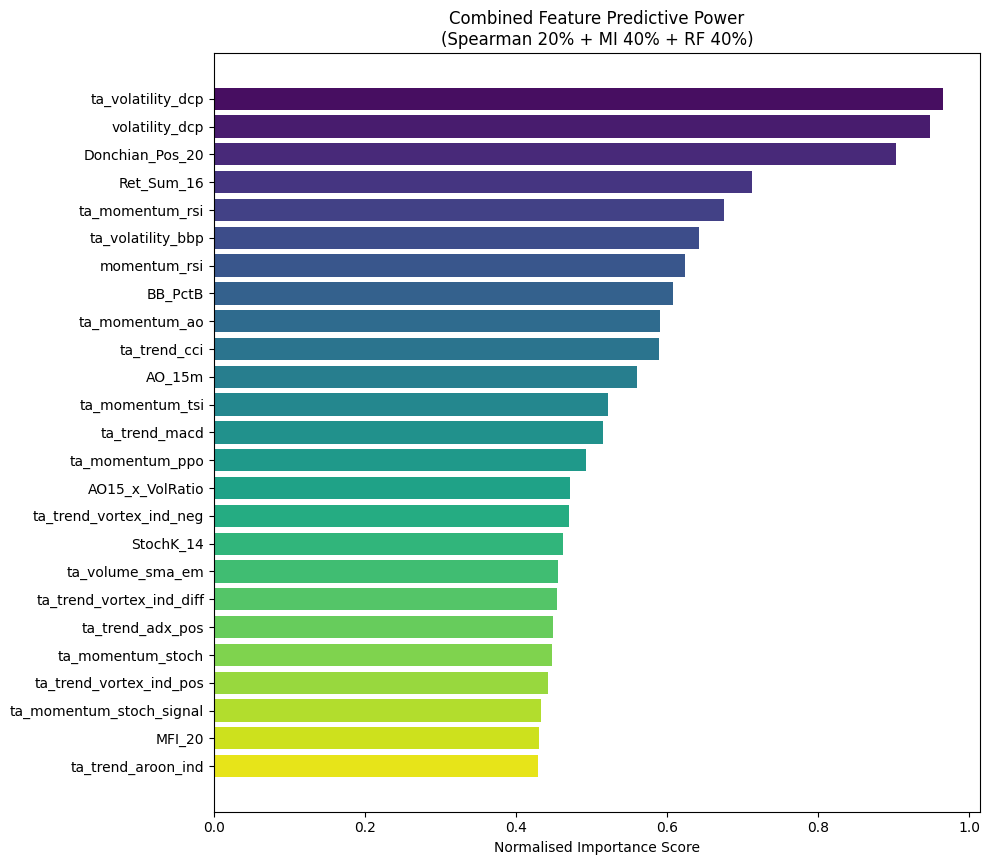

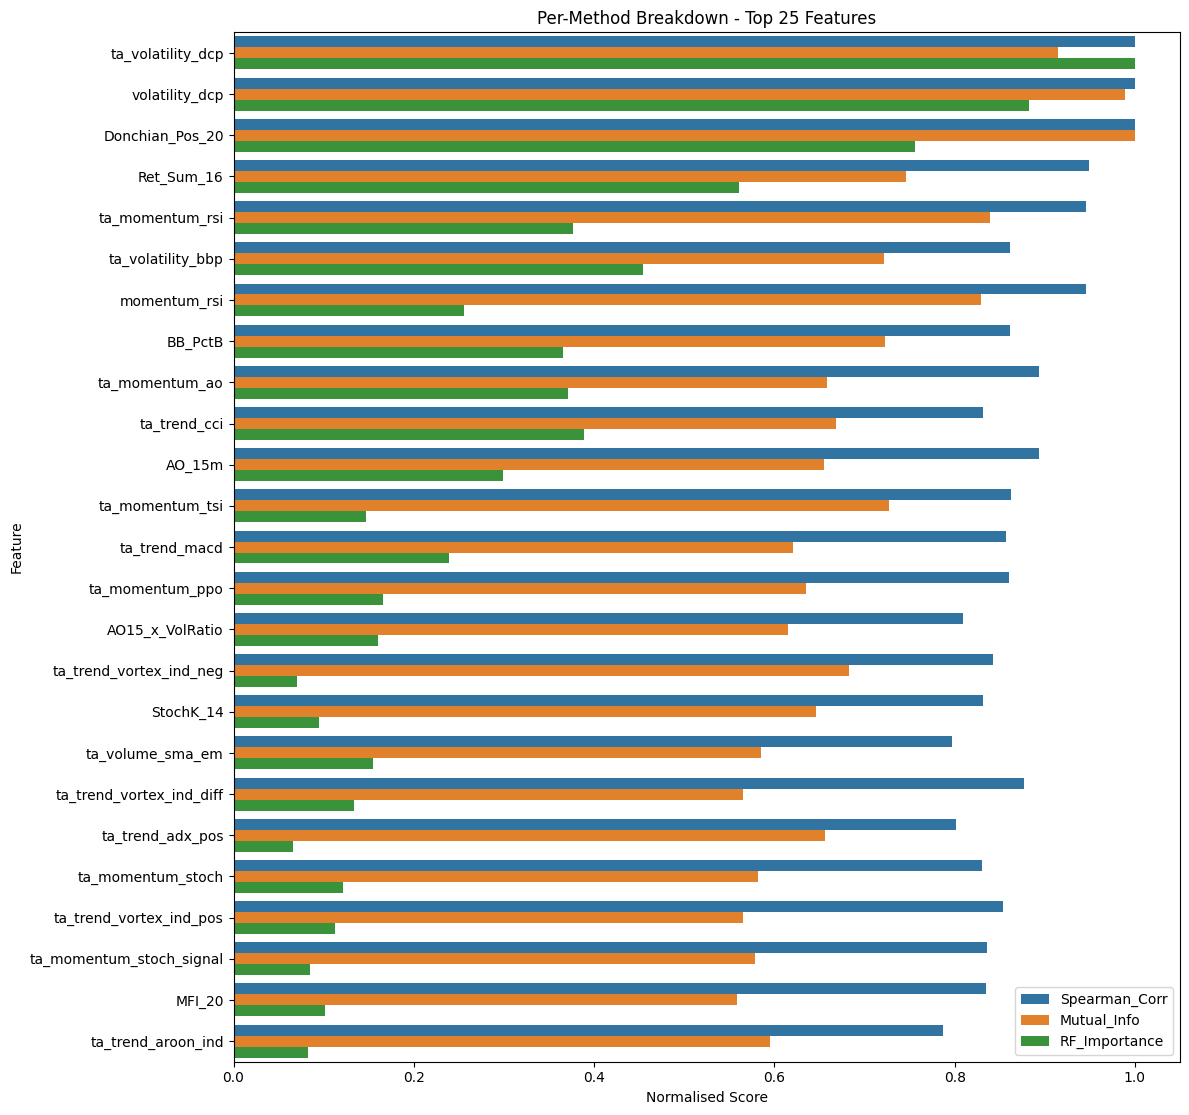

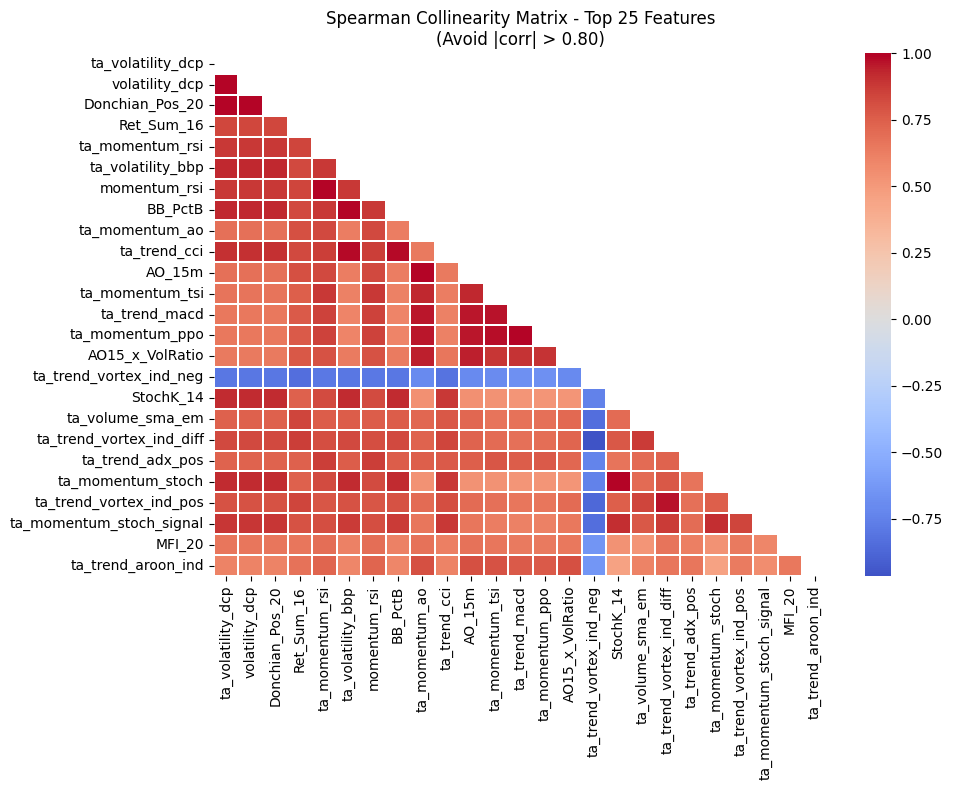

In [20]:
"""
Feature Importance Analysis Framework (Self-Contained)
====================================================
Runs Spearman correlation, Mutual Information, and Random Forest importance
on an overall feature set built from:
1) Unified engineered features from build_all_features
2) Full TA universe from get_all_ta_feature_cols() + ta.add_all_ta_features
"""

import sys
import os
import importlib

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    _nb_dir = os.getcwd()

if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
from ta import add_all_ta_features
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import feature_engineering as fe

# Force-refresh module in notebook kernel to avoid stale import state.
fe = importlib.reload(fe)
build_all_features = fe.build_all_features
get_feature_cols = fe.get_feature_cols


def _safe_get_all_ta_feature_cols(colprefix='ta_'):
    """
    Prefer feature_engineering.get_all_ta_feature_cols; fallback if symbol missing in stale runtime.
    """
    if hasattr(fe, 'get_all_ta_feature_cols'):
        return fe.get_all_ta_feature_cols(colprefix=colprefix)

    print("[Info] get_all_ta_feature_cols not found in loaded module; using local fallback.")

    n = 300
    idx = np.arange(n, dtype=float)
    close = 100.0 + 0.02 * idx + np.sin(idx / 12.0)
    open_ = close * (1.0 + 0.0005 * np.cos(idx / 7.0))
    high = np.maximum(open_, close) * 1.002
    low = np.minimum(open_, close) * 0.998
    volume = 1000.0 + 10.0 * np.mod(idx, 20)

    base = pd.DataFrame(
        {
            'open': open_,
            'high': high,
            'low': low,
            'close': close,
            'volume': volume,
        }
    )

    out = add_all_ta_features(
        base.copy(),
        open='open',
        high='high',
        low='low',
        close='close',
        volume='volume',
        fillna=False,
        colprefix=colprefix,
    )
    return sorted([c for c in out.columns if c not in base.columns])


def evaluate_features(df, feature_cols, target_col='Target', top_n=20):
    """
    Rank feature importance using three complementary methods:
      1. Spearman correlation  - linear/monotonic signal strength
      2. Mutual Information    - non-linear information content
      3. Random Forest         - tree-split importance
    """
    X = df[feature_cols].copy()
    y_raw = df[target_col]                   # continuous 0-1
    y_bin = (y_raw > 0.5).astype(int)        # binary, matches training direction_target

    na_counts = X.isna().sum()
    if na_counts.any():
        print(f"[Warning] {na_counts[na_counts > 0].to_dict()} NaN values found - filling with 0 for analysis.")
        X = X.fillna(0.0)
    # Replace infinity values with 0 (from division by zero in engineered features)
    inf_mask = np.isinf(X)
    if inf_mask.any().any():
        inf_counts = inf_mask.sum()
        print(f"[Warning] {inf_counts[inf_counts > 0].to_dict()} infinity values found - replacing with 0 for analysis.")
        X = X.replace([np.inf, -np.inf], 0.0)
    results = pd.DataFrame(index=feature_cols)

    # 1. Spearman Correlation (vs continuous target - handles outliers)
    print("Calculating Spearman Correlation...")
    corr = X.corrwith(y_raw, method='spearman')
    results['Spearman_Corr'] = corr.abs().fillna(0.0)

    # 2. Mutual Information (classification-style, aligned with direction target)
    print("Calculating Mutual Information (classification)...")
    mi_scores = mutual_info_classif(X, y_bin, random_state=42)
    results['Mutual_Info'] = mi_scores

    # 3. Random Forest importance (binary direction prediction)
    print("Calculating Random Forest Importance...")
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(X, y_bin)
    results['RF_Importance'] = rf.feature_importances_

    # Normalise each metric to [0, 1] so they're on the same scale
    for col in results.columns:
        max_val = results[col].max()
        results[col] = results[col] / max_val if max_val > 0 else results[col]

    results['Final_Score'] = (
        results['Spearman_Corr']  * 0.20 +
        results['Mutual_Info']    * 0.40 +
        results['RF_Importance']  * 0.40
    )
    results = results.sort_values('Final_Score', ascending=False)

    print("\n--- TOP FEATURES BY COMBINED SCORE ---")
    print(results.head(40).round(4).to_string())

    # --- Plot 1: Combined importance bar chart (top_n) ---
    plot_n = min(top_n, len(results))
    plot_df = results.head(plot_n)
    fig, ax = plt.subplots(figsize=(10, max(6, plot_n * 0.35)))
    colors = sns.color_palette('viridis', len(plot_df))
    ax.barh(plot_df.index[::-1], plot_df['Final_Score'][::-1], color=colors[::-1])
    ax.set_xlabel('Normalised Importance Score')
    ax.set_title('Combined Feature Predictive Power\n(Spearman 20% + MI 40% + RF 40%)')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Per-method comparison for top features ---
    top_melted = plot_df[['Spearman_Corr', 'Mutual_Info', 'RF_Importance']].reset_index().melt(
        id_vars='index', var_name='Method', value_name='Score'
    )
    fig, ax = plt.subplots(figsize=(12, max(6, plot_n * 0.45)))
    sns.barplot(data=top_melted, y='index', x='Score', hue='Method', ax=ax)
    ax.set_xlabel('Normalised Score')
    ax.set_ylabel('Feature')
    ax.set_title(f'Per-Method Breakdown - Top {plot_n} Features')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # --- Plot 3: Collinearity heatmap (top N features) ---
    top_names = plot_df.index.tolist()
    fig, ax = plt.subplots(figsize=(10, 8))
    corr_matrix = X[top_names].corr(method='spearman')
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix,
        annot=False, cmap='coolwarm', center=0,
        mask=mask, ax=ax, linewidths=0.3
    )
    ax.set_title(f'Spearman Collinearity Matrix - Top {plot_n} Features\n(Avoid |corr| > 0.80)')
    plt.tight_layout()
    plt.show()

    return results


def prepare_full_feature_dataset(asset='USDCNH', missing_strategy='fill_zero', colprefix='ta_'):
    """
    Build a self-contained analysis dataset from raw MT5 CSV and include full TA features.
    """
    asset = asset.upper()
    if asset == 'USDCNH':
        input_file = 'USDCNH_M15_202401020000_202604131415.csv'
    elif asset == 'CORN':
        input_file = 'CORN.c_M15_202303301000_202604131415.csv'
    else:
        raise ValueError("asset must be 'USDCNH' or 'CORN'")

    print(f"Loading data for {asset} from {input_file}...")
    df = pd.read_csv(input_file, sep='\t')
    df['Datetime'] = pd.to_datetime(df['<DATE>'] + ' ' + df['<TIME>'])
    df = df.rename(columns={
        '<OPEN>': 'Open',
        '<HIGH>': 'High',
        '<LOW>': 'Low',
        '<CLOSE>': 'Close',
        '<TICKVOL>': 'Volume'
    })
    df = df.set_index('Datetime')[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

    # Base indicators required by build_all_features
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    ao_15m = ta.momentum.AwesomeOscillatorIndicator(high=df['High'], low=df['Low'], window1=5, window2=34)
    df['AO_15m'] = ao_15m.awesome_oscillator()
    df['MFI_20'] = ta.volume.MFIIndicator(
        high=df['High'], low=df['Low'], close=df['Close'], volume=df['Volume'], window=20
    ).money_flow_index()

    sma_volume = df['Volume'].rolling(window=20).mean()
    df['Vol_Ratio'] = df['Volume'] / (sma_volume + 1e-8)

    bb = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
    df['BB_PctB'] = bb.bollinger_pband()

    donchian_high = df['High'].rolling(window=20).max()
    donchian_low = df['Low'].rolling(window=20).min()
    df['Donchian_Pos_20'] = (df['Close'] - donchian_low) / (donchian_high - donchian_low + 1e-8)

    # 4H indicators
    df_4h = df.resample('4H').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
    adx_4h = ta.trend.ADXIndicator(high=df_4h['High'], low=df_4h['Low'], close=df_4h['Close'], window=14)
    df_4h['ADX_4H'] = adx_4h.adx()
    ao_4h = ta.momentum.AwesomeOscillatorIndicator(high=df_4h['High'], low=df_4h['Low'], window1=5, window2=34)
    df_4h['AO_4H'] = ao_4h.awesome_oscillator()
    df[['ADX_4H', 'AO_4H']] = df_4h[['ADX_4H', 'AO_4H']].reindex(df.index, method='ffill')

    # 1D indicators
    df_1d = df.resample('1D').agg({'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum'}).dropna()
    adx_1d = ta.trend.ADXIndicator(high=df_1d['High'], low=df_1d['Low'], close=df_1d['Close'], window=14)
    df_1d['ADX_1D'] = adx_1d.adx()
    ao_1d = ta.momentum.AwesomeOscillatorIndicator(high=df_1d['High'], low=df_1d['Low'], window1=5, window2=34)
    df_1d['AO_1D'] = ao_1d.awesome_oscillator()
    df[['ADX_1D', 'AO_1D']] = df_1d[['ADX_1D', 'AO_1D']].reindex(df.index, method='ffill')

    # Add unified engineered features
    df = build_all_features(df, asset=asset)

    # Add full TA family using ta library
    df = add_all_ta_features(
        df.copy(),
        open='Open', high='High', low='Low', close='Close', volume='Volume',
        fillna=False, colprefix=colprefix
    )

    # Build overall candidate feature set from engineered + dynamic TA universe
    engineered_cols = get_feature_cols(asset)
    ta_universe_cols = _safe_get_all_ta_feature_cols(colprefix=colprefix)
    overall_feature_cols = sorted([
        c for c in set(engineered_cols + ta_universe_cols)
        if c in df.columns
    ])

    print(f"Engineered features: {len(engineered_cols)}")
    print(f"TA universe from get_all_ta_feature_cols: {len(ta_universe_cols)}")
    print(f"Overall usable features in this dataset: {len(overall_feature_cols)}")

    # Target
    df['Next_Log_Return'] = np.log(df['Close'].shift(-1) / df['Close'])
    rolling_std = df['Next_Log_Return'].rolling(window=20).std()
    rolling_mean = df['Next_Log_Return'].rolling(window=20).mean()
    df['Target'] = ((df['Next_Log_Return'] - rolling_mean) / (2 * rolling_std) + 0.5).clip(0, 1)
    df = df.drop(columns=['Next_Log_Return'])

    if missing_strategy == 'fill_zero':
        df[overall_feature_cols] = df[overall_feature_cols].fillna(0.0)
        df = df.dropna(subset=['Target'])
    elif missing_strategy == 'drop':
        df = df.dropna(subset=overall_feature_cols + ['Target'])
    else:
        raise ValueError("missing_strategy must be 'drop' or 'fill_zero'")

    return df, overall_feature_cols


# ==========================================
# RUN SELF-CONTAINED OVERALL FEATURE ANALYSIS
# ==========================================
ASSET = 'CORN'            # 'USDCNH' or 'CORN'
MISSING_STRATEGY = 'fill_zero'
TOP_N = 25
input_file = "CORN.c_M15_202303301000_202604131415.csv"

analysis_df, overall_feature_cols = prepare_full_feature_dataset(
    asset=ASSET,
    missing_strategy=MISSING_STRATEGY,
    colprefix='ta_'
)

print(f"Analysis rows: {len(analysis_df)}")
print(f"Feature for analysis: {(overall_feature_cols)}")
importance_results = evaluate_features(
    analysis_df,
    overall_feature_cols,
    target_col='Target',
    top_n=TOP_N
)

# current_results = evaluate_features(output_df, feature_cols, target_col='Target', top_n=TOP_N)

In [3]:
import os
import pandas as pd
import datetime as dt
import akshare as ak
import yfinance as yf


def fetch_us10y_yfinance(start_date: str):
    """
    Fetch US10Y from yfinance (^TNX)
    Note: ^TNX = 10Y yield * 10
    """
    try:
        df = yf.download("^TNX", start=start_date, progress=False)
        if df.empty:
            return pd.DataFrame()

        df = df.reset_index()
        df["date"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")

        # Convert TNX to real yield
        df["美国国债收益率10年"] = df["Close"] / 10.0

        return df[["date", "美国国债收益率10年"]]

    except Exception as e:
        print("yfinance fallback failed:", e)
        return pd.DataFrame()


def update_bond_zh_us_rates(csv_path: str, start_default: str = "2015-01-01") -> None:
    today = dt.date.today()
    start_date = start_default

    # ======================
    # 1. LOAD EXISTING
    # ======================
    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        if not existing.empty:
            last_date = pd.to_datetime(existing["date"]).max().date()
            start_date = (last_date + dt.timedelta(days=1)).strftime("%Y-%m-%d")
        else:
            existing = pd.DataFrame()
    else:
        existing = pd.DataFrame()

    # ======================
    # 2. FETCH AKSHARE
    # ======================
    ak_data = pd.DataFrame()
    try:
        if pd.to_datetime(start_date).date() <= today:
            ak_data = ak.bond_zh_us_rate(start_date=start_date)

            if not ak_data.empty:
                ak_data["date"] = pd.to_datetime(ak_data["日期"]).dt.strftime("%Y-%m-%d")
                ak_data.drop(["日期"], axis=1, inplace=True)
    except Exception as e:
        print("AKShare failed:", e)

    # ======================
    # 3. FETCH YFINANCE (fallback)
    # ======================
    yf_data = fetch_us10y_yfinance(start_date)

    # ======================
    # 4. MERGE DATA SOURCES
    # ======================
    if not ak_data.empty and not yf_data.empty:
        merged = pd.merge(ak_data, yf_data, on="date", how="outer", suffixes=("", "_yf"))

        # fill missing US10Y from yfinance
        if "美国国债收益率10年" in merged.columns and "美国国债收益率10年_yf" in merged.columns:
            merged["美国国债收益率10年"] = merged["美国国债收益率10年"].fillna(
                merged["美国国债收益率10年_yf"]
            )
            merged.drop(columns=["美国国债收益率10年_yf"], inplace=True)

    elif not ak_data.empty:
        merged = ak_data

    elif not yf_data.empty:
        merged = yf_data

    else:
        print("No new data fetched.")
        merged = pd.DataFrame()

    # ======================
    # 5. CONCAT WITH EXISTING
    # ======================
    if existing.empty:
        combined = merged
    else:
        combined = pd.concat([existing, merged], ignore_index=True)
        combined = combined.drop_duplicates(subset=["date"], keep="last")

    if combined.empty:
        print("No data available.")
        return

    # ======================
    # 6. CLEAN & SORT
    # ======================
    combined.sort_values("date", inplace=True)

    base_cols = []

    for c in combined.columns:
        if c == "date":
            continue
        if "_change" in c or "_pct_change" in c:
            continue
        
        # 🔴 ensure it's a Series, not DataFrame
        if isinstance(combined[c], pd.Series):
            base_cols.append(c)

    combined = combined[["date"] + base_cols]

    # ======================
    # 7. FILTER INVALID ROWS
    # ======================
    us_core_cols = [
        c for c in ["美国国债收益率10年"] if c in combined.columns
    ]

    if us_core_cols:
        for col in us_core_cols:
            combined[col] = pd.to_numeric(combined[col], errors="coerce")

        combined = combined.dropna(subset=us_core_cols, how="all")

    # ======================
    # 8. FEATURE ENGINEERING
    # ======================
    for col in base_cols:
        combined[f"{col}_change"] = combined[col].diff()
        combined[f"{col}_pct_change"] = combined[col].pct_change(fill_method=None)

    # ======================
    # 9. SAVE
    # ======================
    combined.to_csv(csv_path, index=False)
    print(f"Updated: {csv_path}, rows={len(combined)}")


In [ ]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import akshare as ak
import yfinance as yf


CSV_PATH = "bond_data.csv"


# ======================
# UTIL: CLEAN COLUMNS (CRITICAL)
# ======================

def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    # flatten MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            "_".join([str(i) for i in col if i]).strip("_")
            for col in df.columns
        ]

    # convert all to string
    df.columns = [str(c).strip() for c in df.columns]

    # remove duplicate columns (keep first)
    df = df.loc[:, ~df.columns.duplicated()]

    return df


# ======================
# 1. FETCH US10Y
# ======================

def fetch_us10y_yfinance(start_date: str):
    try:
        df = yf.download("^TNX", start=start_date, progress=False)

        if df.empty:
            return pd.DataFrame()

        df = df.reset_index()
        df["date"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")

        # TNX = yield * 10
        df["美国国债收益率10年"] = df["Close"] / 10.0

        return df[["date", "美国国债收益率10年"]]

    except Exception as e:
        print("yfinance error:", e)
        return pd.DataFrame()


# ======================
# 2. UPDATE DATA
# ======================

def update_bond_data(csv_path: str):
    today = dt.date.today()
    start_date = "2015-01-01"

    # load existing
    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        existing = clean_columns(existing)

        if not existing.empty:
            last_date = pd.to_datetime(existing["date"]).max().date()
            start_date = (last_date + dt.timedelta(days=1)).strftime("%Y-%m-%d")
    else:
        existing = pd.DataFrame()

    # ----------------------
    # AKShare
    # ----------------------
    ak_data = pd.DataFrame()
    try:
        if pd.to_datetime(start_date).date() <= today:
            ak_data = ak.bond_zh_us_rate(start_date=start_date)

            if not ak_data.empty:
                ak_data["date"] = pd.to_datetime(ak_data["日期"]).dt.strftime("%Y-%m-%d")
                ak_data.drop(columns=["日期"], inplace=True)

    except Exception as e:
        print("AKShare failed:", e)

    ak_data = clean_columns(ak_data)

    # ----------------------
    # yfinance fallback
    # ----------------------
    yf_data = fetch_us10y_yfinance(start_date)
    yf_data = clean_columns(yf_data)

    # ----------------------
    # merge
    # ----------------------
    if not ak_data.empty and not yf_data.empty:
        merged = pd.merge(ak_data, yf_data, on="date", how="outer")

        if "美国国债收益率10年_x" in merged.columns:
            merged["美国国债收益率10年"] = merged["美国国债收益率10年_x"].combine_first(
                merged.get("美国国债收益率10年_y")
            )
            merged.drop(columns=[c for c in merged.columns if c.endswith("_x") or c.endswith("_y")], inplace=True)

    elif not ak_data.empty:
        merged = ak_data
    else:
        merged = yf_data

    merged = clean_columns(merged)

    # ----------------------
    # combine with existing
    # ----------------------
    if existing.empty:
        combined = merged
    else:
        combined = pd.concat([existing, merged], ignore_index=True)

    combined = clean_columns(combined)

    if "date" not in combined.columns:
        raise ValueError(f"'date' column missing. Columns: {combined.columns.tolist()}")

    combined.drop_duplicates(subset=["date"], keep="last", inplace=True)
    combined.sort_values("date", inplace=True)

    # ----------------------
    # enforce US10Y
    # ----------------------
    if "美国国债收益率10年" not in combined.columns:
        raise ValueError("Missing US10Y column after merge")

    combined["美国国债收益率10年"] = pd.to_numeric(
        combined["美国国债收益率10年"], errors="coerce"
    )

    combined.dropna(subset=["美国国债收益率10年"], inplace=True)

    # ======================
    # FEATURE ENGINEERING (SAFE)
    # ======================

    numeric_cols = []

    for col in combined.columns:
        if col == "date":
            continue

        combined[col] = pd.to_numeric(combined[col], errors="coerce")

        # only keep real numeric series
        if combined[col].notna().sum() > 10:
            numeric_cols.append(col)

    # compute changes ONLY on numeric cols
    for col in numeric_cols:
        combined[f"{col}_change"] = combined[col].diff()
        combined[f"{col}_pct_change"] = combined[col].pct_change()

    combined.to_csv(csv_path, index=False)

    return combined


# ======================
# 3. MARKET DATA
# ======================

def safe_last_return(df, name="unknown"):
    if df is None or len(df) < 2:
        print(f"[WARN] {name}: not enough data")
        return None

    # 🔴 forward fill missing values
    df = df.ffill()

    # still all NaN?
    if df.dropna().empty:
        print(f"[WARN] {name}: all NaN even after ffill")
        return None

    ret = df.pct_change()

    if ret.empty:
        print(f"[WARN] {name}: empty returns")
        return None

    last = ret.iloc[-1]

    # scalar case
    if not isinstance(last, pd.Series):
        if pd.isna(last):
            print(f"[WARN] {name}: last value NaN")
            return None
        return float(last)

    # Series case
    last = last.dropna()

    if last.empty:
        print(f"[WARN] {name}: last row NaN after ffill")
        return None

    return float(last.iloc[0])


def fetch_market():
    nasdaq = yf.download("^IXIC", period="5d", progress=False)
    vix = yf.download("^VIX", period="5d", progress=False)
    cnh = yf.download("CNH=X", period="5d", progress=False)

    # ALWAYS use full df, not ["Close"] yet
    nasdaq_close = nasdaq["Close"]
    vix_close = vix["Close"]
    cnh_close = cnh["Close"]

    nasdaq_ret = safe_last_return(nasdaq_close)
    vix_ret = safe_last_return(vix_close)
    cnh_move = safe_last_return(cnh_close)

    sentiment = nasdaq_ret - vix_ret

    return sentiment, cnh_move


# ======================
# 4. VOL MODE
# ======================

def judge_vol_mode(df):
    series = df["美国国债收益率10年"]

    vol_2d = series.pct_change().tail(2).std()
    range_5d = series.tail(5).max() - series.tail(5).min()
    vol_threshold = series.pct_change().tail(30).std()

    if vol_2d > vol_threshold and range_5d > 0.1:
        return "BROAD_VOL", vol_2d, range_5d
    return "NARROW_VOL", vol_2d, range_5d


# ======================
# 5. SIGNAL
# ======================

def generate_signal(vol_mode, north_flow, cnh_move, sentiment):
    # 🔴 if key data missing → NO TRADE
    if cnh_move is None or sentiment is None:
        return "NO_TRADE"

    if vol_mode == "NARROW_VOL":
        return "NO_TRADE"

    if north_flow < -20 and cnh_move > 0.002 and sentiment < -0.01:
        return "SHORT_ASSET"
    elif north_flow > 20 and cnh_move < -0.002 and sentiment > 0.01:
        return "LONG_ASSET"
    else:
        return "LIGHT_HEDGE"


def position_control(signal):
    return {
        "LONG_ASSET": ("30%-50%", "1-2d"),
        "SHORT_ASSET": ("20%-40%", "1-3d"),
        "LIGHT_HEDGE": ("<10%", "1d"),
        "NO_TRADE": ("0%", "0d"),
    }[signal]
def safe_fmt(x):
    return "NA" if x is None else f"{x:.4f}"

# ======================
# MAIN
# ======================

def run_model():
    print("Updating data...")
    df = update_bond_data(CSV_PATH)

    print("Fetching market...")
    sentiment, cnh_move = fetch_market()

    north_flow = 3224.78  # manual input

    vol_mode, vol_2d, range_5d = judge_vol_mode(df)

    signal = generate_signal(vol_mode, north_flow, cnh_move, sentiment)
    position = position_control(signal)

    print("\n====== RESULT ======")
    print(f"Vol Mode: {vol_mode}")
    print(f"2D Vol: {vol_2d:.6f}")
    print(f"5D Range: {range_5d:.4f}")
    print(f"Sentiment: {safe_fmt(sentiment)}")
    print(f"CNH Move: {safe_fmt(cnh_move)}")
    print(f"North Flow: {north_flow}")
    print(f"\nSignal: {signal}")
    print(f"Position: {position}")


if __name__ == "__main__":
    run_model()

Updating data...


Exception ignored in: <function tqdm.__del__ at 0x794b890d9750>
Traceback (most recent call last):
  File "/workspaces/time_series_cross_sectional_analyse/.venv/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/workspaces/time_series_cross_sectional_analyse/.venv/lib/python3.10/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


AKShare failed: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


/tmp/ipykernel_3155152/4247368166.py:165: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  combined[f"{col}_pct_change"] = combined[col].pct_change()
/tmp/ipykernel_3155152/4247368166.py:165: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  combined[f"{col}_pct_change"] = combined[col].pct_change()
/tmp/ipykernel_3155152/4247368166.py:165: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  combined[f"{col}_pct_

Fetching market...
[WARN] unknown: not enough data

====== RESULT ======
Vol Mode: NARROW_VOL
2D Vol: 0.006392
5D Range: 0.0044
Sentiment: 0.0389
CNH Move: NA
North Flow: 3224.78

Signal: NO_TRADE
Position: ('0%', '0d')


: 